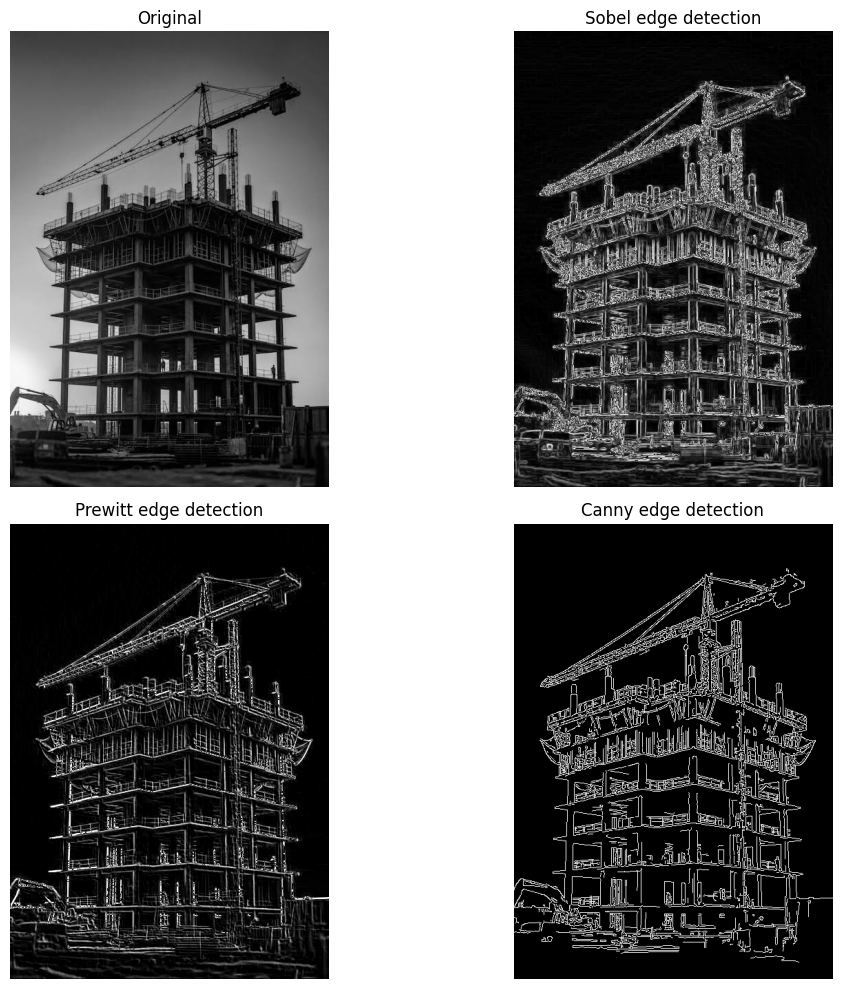

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def show_comparsion(original,sobel,prewitt,canny):
  plt.figure(figsize=(12,10))
  plt.subplot(2,2,1)
  plt.imshow(original,cmap='gray')
  plt.title('Original')
  plt.axis('off')
  plt.subplot(2,2,2)
  plt.imshow(sobel,cmap='gray')
  plt.title('Sobel edge detection')
  plt.axis('off')
  plt.subplot(2,2,3)
  plt.imshow(prewitt,cmap='gray')
  plt.title('Prewitt edge detection')
  plt.axis('off')
  plt.subplot(2,2,4)
  plt.imshow(canny,cmap='gray')
  plt.title('Canny edge detection')
  plt.axis('off')
  plt.tight_layout()
  plt.show()
img = cv2.imread('/content/building.jfif',0)
if img is None:
    print('Failed to load image')
else:
    sobelx = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)
    sobely = cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3)
    sobel_combined = cv2.magnitude(sobelx,sobely)
    kernalx = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
    kernaly = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
    prewittx = cv2.filter2D(img,-1,kernalx)
    prewitty = cv2.filter2D(img,-1,kernaly)
    prewitt_combined = prewittx + prewitty
    canny_edges = cv2.Canny(img,100,200)
show_comparsion(img,np.uint8(np.absolute(sobel_combined)),prewitt_combined,canny_edges)
